In [1]:
import pandas as pd
import numpy as np
import json
import re
from urllib.parse import urlparse, parse_qs
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Optional: set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv("network-requests-10k-20k.csv")  # rows per chunk) #2,996,728
df.dropna(inplace=True)

In [3]:
import json

def get_initiator_type(x):
    try:
        return json.loads(x).get("type")
    except Exception:
        return None

df_filtered = df[
    df["initiator"].apply(get_initiator_type) != "other"
]

In [4]:
df_filtered.sample(1000).to_csv("random_sample_1000.csv")

In [5]:
# Make a copy to avoid modifying original
df_clean = df_filtered.copy()

# ---- Parse initiator column ----
def parse_initiator(init_str):
    """Convert initiator JSON string to dict, return type and initiating URL."""
    if pd.isna(init_str):
        return pd.Series([np.nan, np.nan, np.nan])
    try:
        init_dict = json.loads(init_str) if isinstance(init_str, str) else init_str
        init_type = init_dict.get('type')
        # Extract the top-level URL if present, else from stack if available
        url = init_dict.get('url')
        stack_depth = np.nan
        if 'stack' in init_dict and 'callFrames' in init_dict['stack']:
            stack_depth = len(init_dict['stack']['callFrames'])
        return pd.Series([init_type, url, stack_depth])
    except:
        return pd.Series([np.nan, np.nan, np.nan])

df_clean[['initiator_type', 'initiator_url', 'stack_depth']] = df_clean['initiator'].apply(parse_initiator)

# ---- Extract file extension from request_url ----
def get_extension(url):
    if pd.isna(url):
        return np.nan
    path = urlparse(url).path
    match = re.search(r'\.([a-zA-Z0-9]+)(?:$|\?)', path)
    return match.group(1).lower() if match else 'no_extension'

df_clean['file_ext'] = df_clean['request_url'].apply(get_extension)

# ---- Parse URL components for request_url ----
def parse_url_components(url):
    if pd.isna(url):
        return pd.Series([np.nan, np.nan, np.nan, np.nan])
    parsed = urlparse(url)
    return pd.Series([parsed.scheme, parsed.netloc, parsed.path, parsed.query])

df_clean[['req_scheme', 'req_netloc', 'req_path', 'req_query']] = df_clean['request_url'].apply(parse_url_components)

# ---- Parse URL components for landing page url (the crawled page) ----
def parse_landing_url(url):
    if pd.isna(url):
        return pd.Series([np.nan, np.nan])
    parsed = urlparse(url)
    return pd.Series([parsed.scheme, parsed.netloc])

df_clean[['landing_scheme', 'landing_netloc']] = df_clean['url'].apply(parse_landing_url)

# ---- First-party vs third-party classification ----
def is_first_party(row):
    req_domain = row['domain']
    landing_domain = row['landing_domain']
    if pd.isna(req_domain) or pd.isna(landing_domain):
        return np.nan
    # Compare domain (already extracted, may include subdomains)
    return req_domain in landing_domain

df_clean['is_first_party'] = df_clean.apply(is_first_party, axis=1)

# ---- Categorize request by known tracker/ad/CDN lists (example) ----
# You can expand with public lists (e.g., from EasyList, Disconnect)
tracker_domains = ['google-analytics.com', 'googletagmanager.com', 'doubleclick.net',
                   'facebook.com', 'amazon-adsystem.com', 'c.amazon-adsystem.com',
                   'adnxs.com', 'rubiconproject.com', 'casalemedia.com', 'outbrain.com',
                   'taboola.com', 'criteo.com', 'pubmatic.com', 'openx.net']
cdn_domains = ['cloudflare.com', 'akamaihd.net', 'fastly.net', 'jsdelivr.net',
               'bootstrapcdn.com', 'cloudfront.net', 'stackpathcdn.com']

def categorize_domain(domain):
    if pd.isna(domain):
        return 'unknown'
    domain_lower = domain.lower()
    if any(t in domain_lower for t in tracker_domains):
        return 'tracker'
    elif any(c in domain_lower for c in cdn_domains):
        return 'cdn'
    else:
        return 'other'

df_clean['domain_category'] = df_clean['domain'].apply(categorize_domain)

# ---- Extract query parameters for mining ----
def extract_query_keys(query):
    if pd.isna(query) or query == '':
        return []
    parsed = parse_qs(query)
    return list(parsed.keys())

df_clean['query_keys'] = df_clean['req_query'].apply(extract_query_keys)

print("Data preparation completed. Shape:", df_clean.shape)
df_clean.head()

Data preparation completed. Shape: (1670102, 18)


,request_url,url,domain,landing_domain,initiator,initiator_type,initiator_url,stack_depth,file_ext,req_scheme,req_netloc,req_path,req_query,landing_scheme,landing_netloc,is_first_party,domain_category,query_keys
4,https://www.google.com/xjs/_/ss/k=xjs.hd.ndS3i...,http://google.mg,google.mg,about.google,"{""url"": ""https://www.google.com/"", ""type"": ""pa...",parser,https://www.google.com/,NaN,no_extension,https,www.google.com,/xjs/_/ss/k=xjs.hd.ndS3iyblYv0.L.B1.O/am=AEAAA...,,http,google.mg,False,other,[]
5,https://www.google.com/logos/doodles/2026/dr-m...,http://google.mg,google.mg,about.google,"{""url"": ""https://www.google.com/"", ""type"": ""pa...",parser,https://www.google.com/,NaN,webp,https,www.google.com,/logos/doodles/2026/dr-martin-luther-king-jr-d...,,http,google.mg,False,other,[]
6,https://fonts.gstatic.com/s/roboto/v18/KFOmCnq...,http://google.mg,google.mg,about.google,"{""url"": ""https://www.google.com/"", ""type"": ""pa...",parser,https://www.google.com/,NaN,woff2,https,fonts.gstatic.com,/s/roboto/v18/KFOmCnqEu92Fr1Mu4mxK.woff2,,http,google.mg,False,other,[]
7,https://www.gstatic.com/kpui/social/fb_32x32.png,http://google.mg,google.mg,about.google,"{""url"": ""https://www.google.com/"", ""type"": ""pa...",parser,https://www.google.com/,NaN,png,https,www.gstatic.com,/kpui/social/fb_32x32.png,,http,google.mg,False,other,[]
8,https://www.gstatic.com/kpui/social/x_32x32.png,http://google.mg,google.mg,about.google,"{""url"": ""https://www.google.com/"", ""type"": ""pa...",parser,https://www.google.com/,NaN,png,https,www.gstatic.com,/kpui/social/x_32x32.png,,http,google.mg,False,other,[]


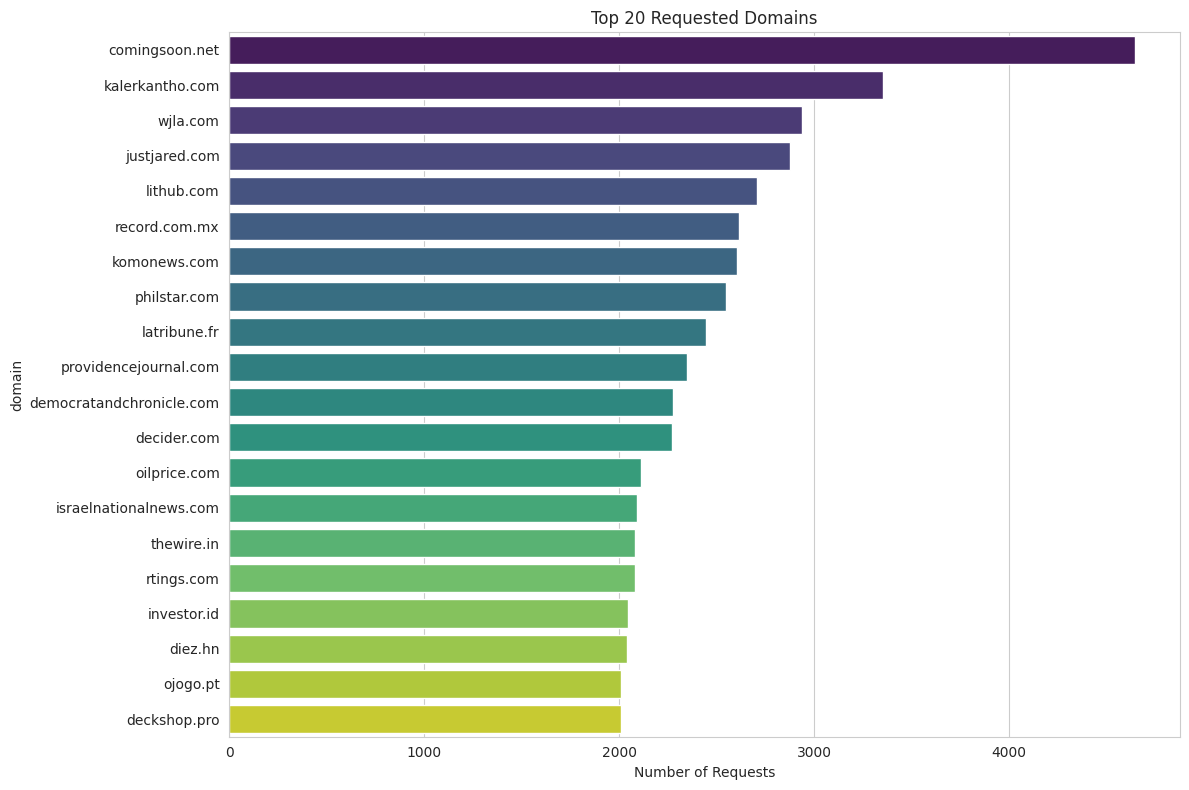

In [ ]:
top_domains = df_clean['domain'].value_counts().head(20)

plt.figure(figsize=(12,8))
sns.barplot(x=top_domains.values, y=top_domains.index, palette='viridis')
plt.title('Top 20 Requested Domains')
plt.xlabel('Number of Requests')
plt.tight_layout()
plt.show()``

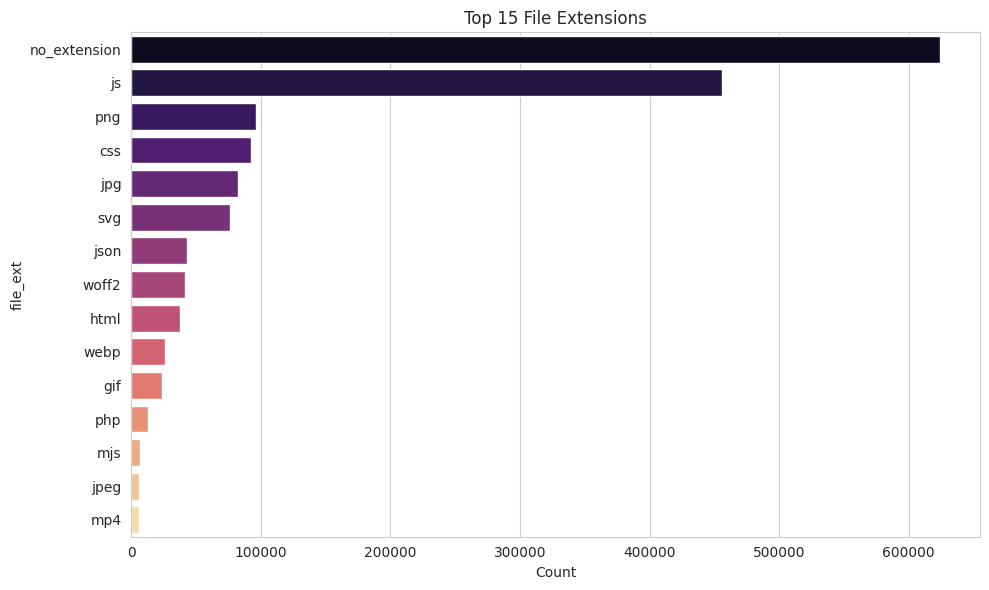

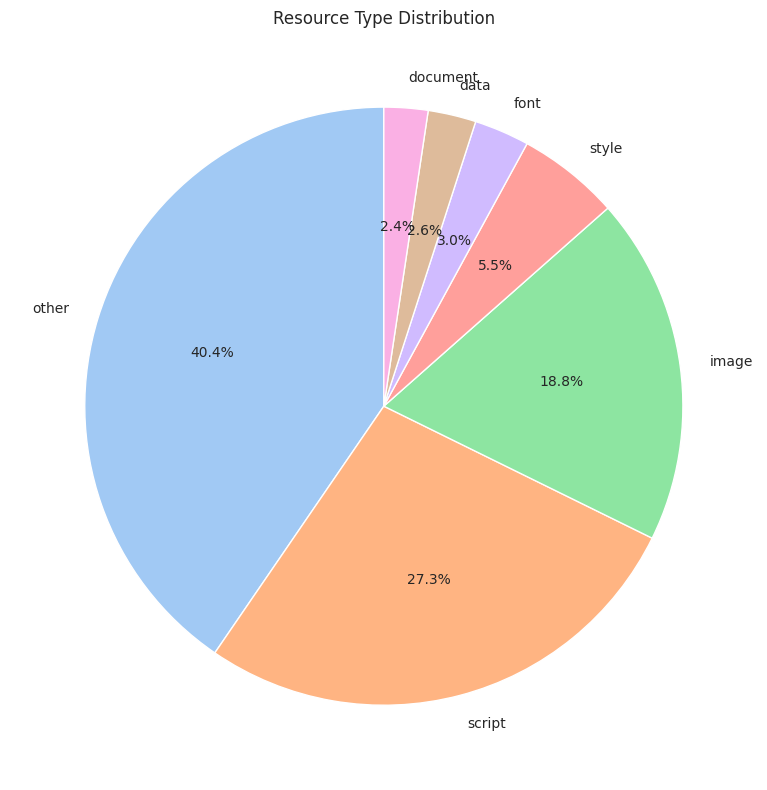

In [7]:
ext_counts = df_clean['file_ext'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=ext_counts.values, y=ext_counts.index, palette='magma')
plt.title('Top 15 File Extensions')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Pie chart for high-level categories
def categorize_ext(ext):
    if ext in ['js']:
        return 'script'
    elif ext in ['css']:
        return 'style'
    elif ext in ['png','jpg','jpeg','gif','svg','webp','ico']:
        return 'image'
    elif ext in ['woff','woff2','ttf','eot']:
        return 'font'
    elif ext in ['html','htm']:
        return 'document'
    elif ext in ['json','xml']:
        return 'data'
    else:
        return 'other'

df_clean['ext_category'] = df_clean['file_ext'].apply(categorize_ext)
ext_cat_counts = df_clean['ext_category'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(ext_cat_counts, labels=ext_cat_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Resource Type Distribution')
plt.tight_layout()
plt.show()

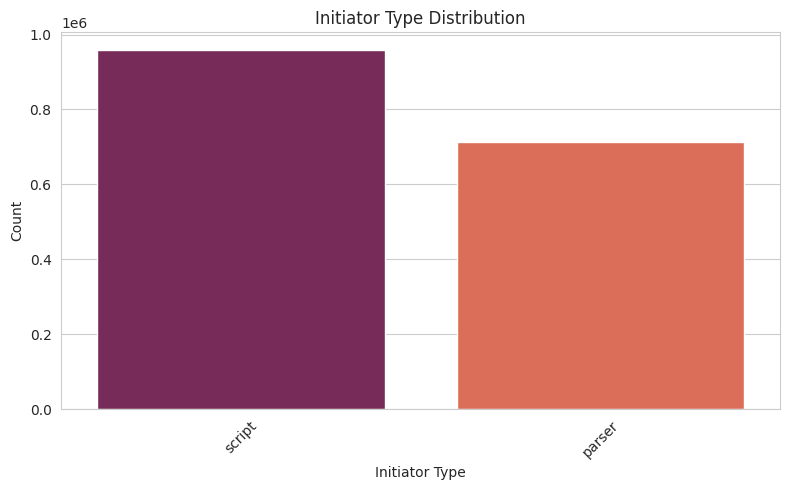

In [8]:
init_counts = df_clean['initiator_type'].value_counts(dropna=False)

plt.figure(figsize=(8,5))
sns.barplot(x=init_counts.index.astype(str), y=init_counts.values, palette='rocket')
plt.title('Initiator Type Distribution')
plt.xlabel('Initiator Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

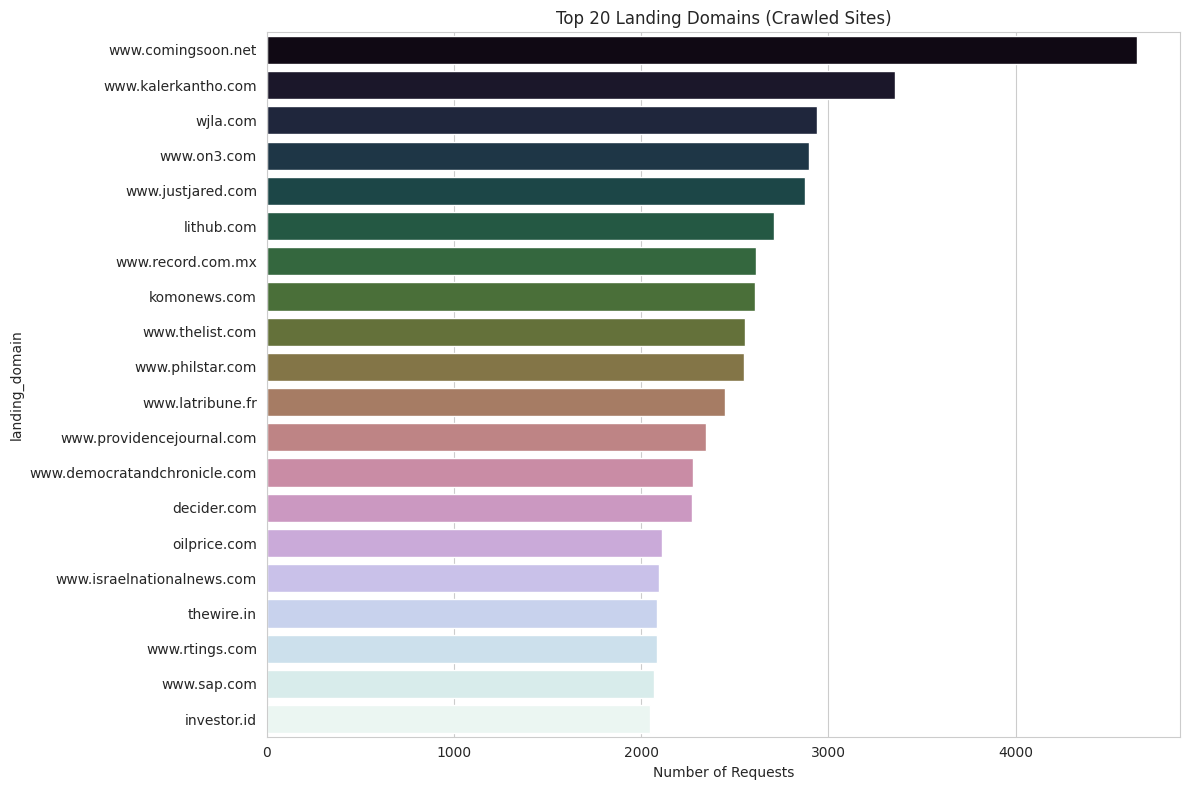

In [9]:
top_landing = df_clean['landing_domain'].value_counts().head(20)

plt.figure(figsize=(12,8))
sns.barplot(x=top_landing.values, y=top_landing.index, palette='cubehelix')
plt.title('Top 20 Landing Domains (Crawled Sites)')
plt.xlabel('Number of Requests')
plt.tight_layout()
plt.show()

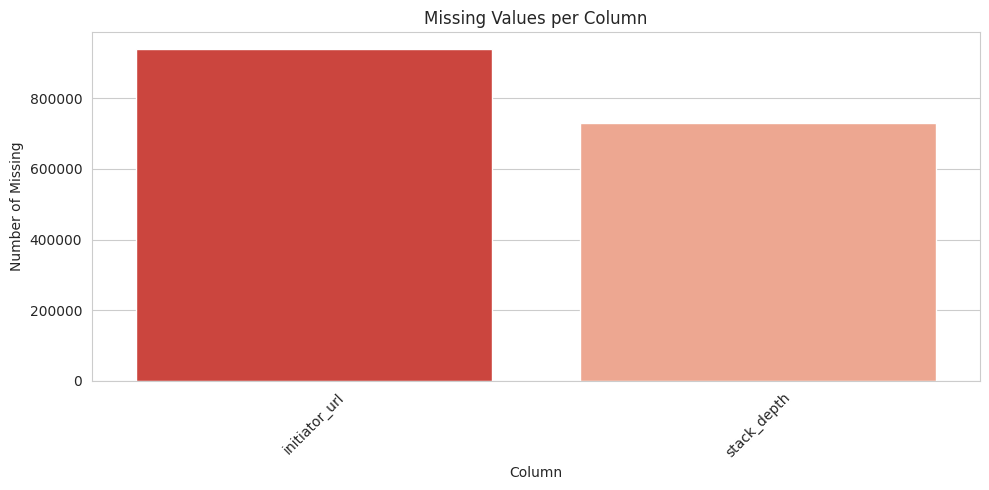

In [10]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing.index, y=missing.values, palette='Reds_r')
plt.title('Missing Values per Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

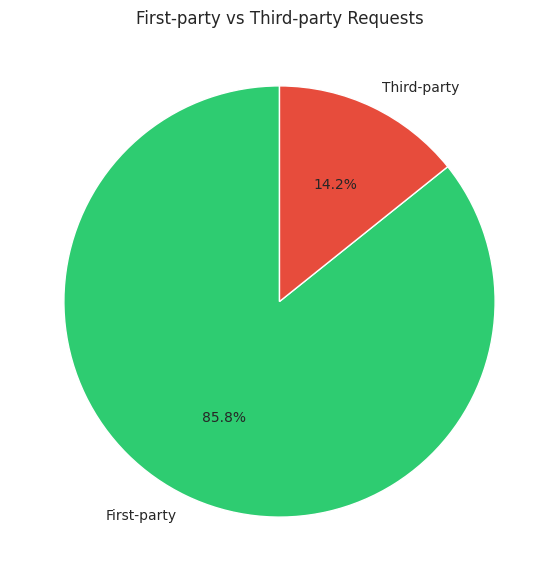

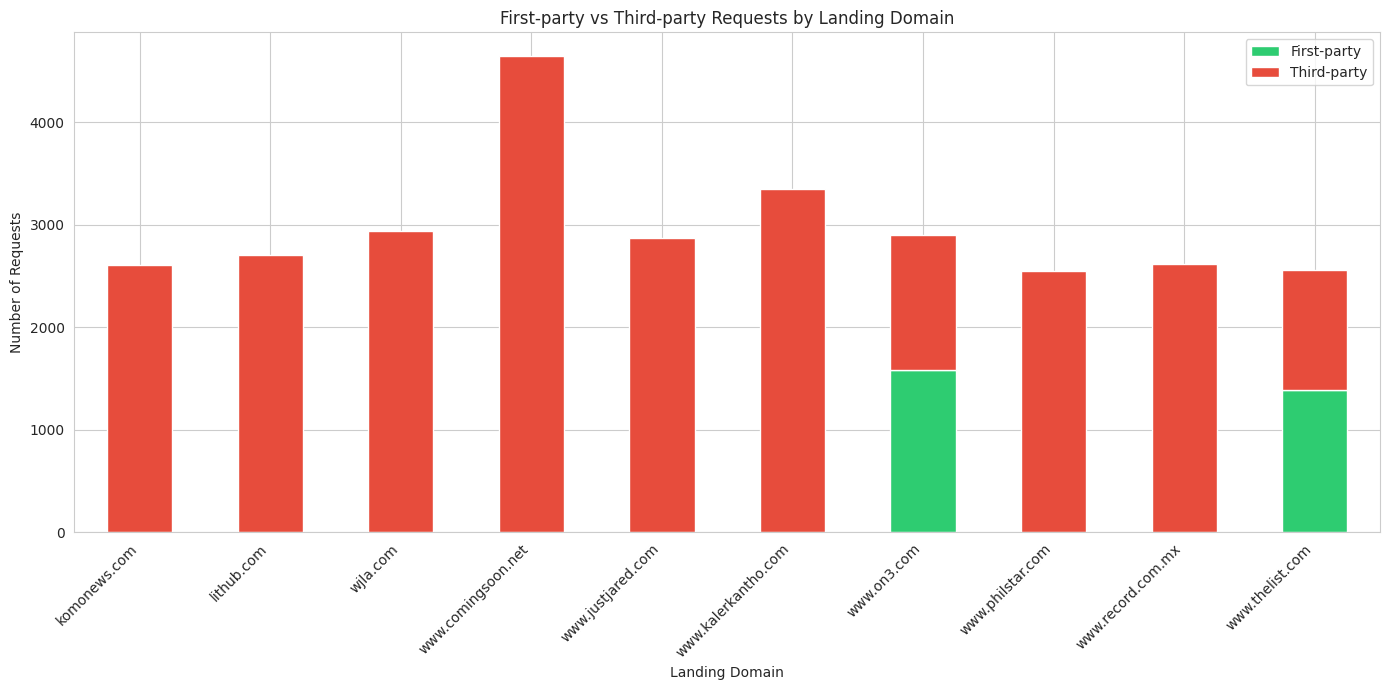

In [11]:
# Overall proportion
party_counts = df_clean['is_first_party'].value_counts(dropna=False)
labels = ['First-party' if x==True else 'Third-party' if x==False else 'Unknown' for x in party_counts.index]

plt.figure(figsize=(7,7))
plt.pie(party_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#2ecc71','#e74c3c','#95a5a6'])
plt.title('First-party vs Third-party Requests')
plt.show()

# Per landing domain (top 10)
top_landings = df_clean['landing_domain'].value_counts().head(10).index
df_top = df_clean[df_clean['landing_domain'].isin(top_landings)]
party_by_landing = df_top.groupby(['landing_domain', 'is_first_party']).size().unstack(fill_value=0)
party_by_landing.plot(kind='bar', stacked=True, figsize=(14,7), color=['#2ecc71','#e74c3c','#95a5a6'])
plt.title('First-party vs Third-party Requests by Landing Domain')
plt.xlabel('Landing Domain')
plt.ylabel('Number of Requests')
plt.legend(['First-party','Third-party','Unknown'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

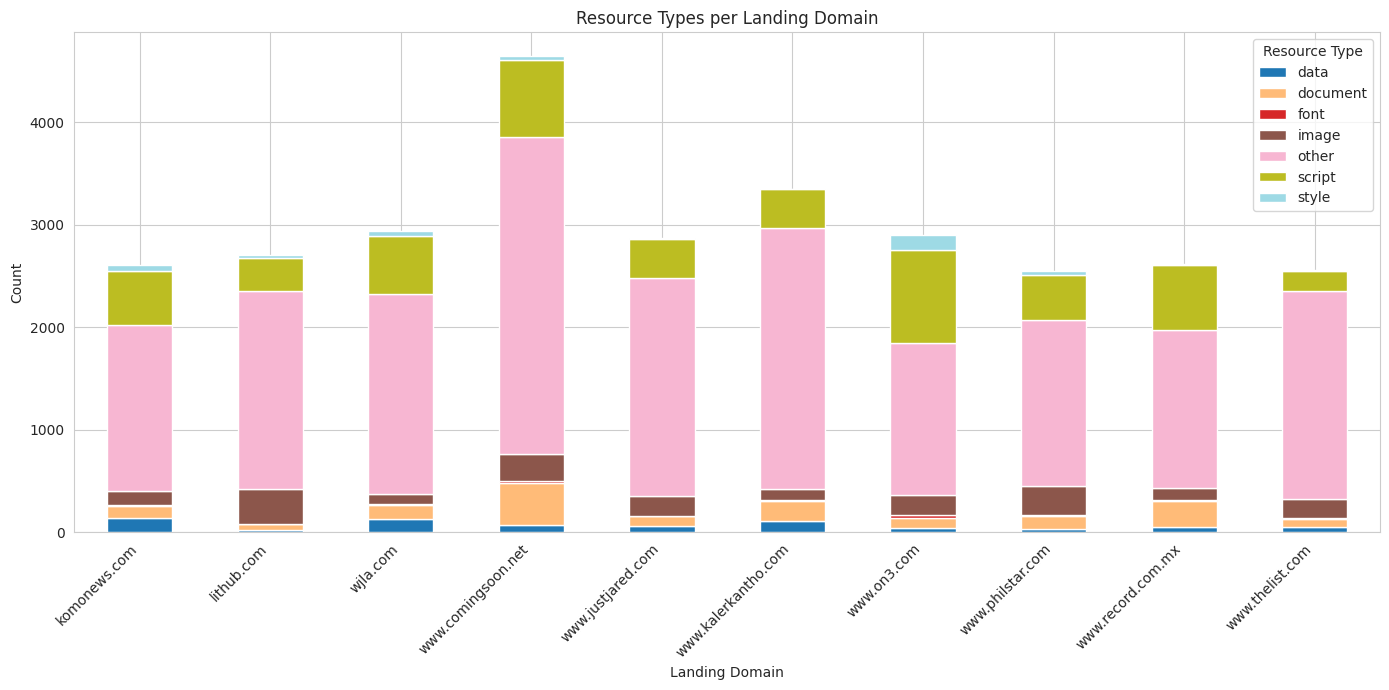

In [12]:
top_landings = df_clean['landing_domain'].value_counts().head(10).index
df_top = df_clean[df_clean['landing_domain'].isin(top_landings)]
resource_by_landing = pd.crosstab(df_top['landing_domain'], df_top['ext_category'])
resource_by_landing.plot(kind='bar', stacked=True, figsize=(14,7), colormap='tab20')
plt.title('Resource Types per Landing Domain')
plt.xlabel('Landing Domain')
plt.ylabel('Count')
plt.legend(title='Resource Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

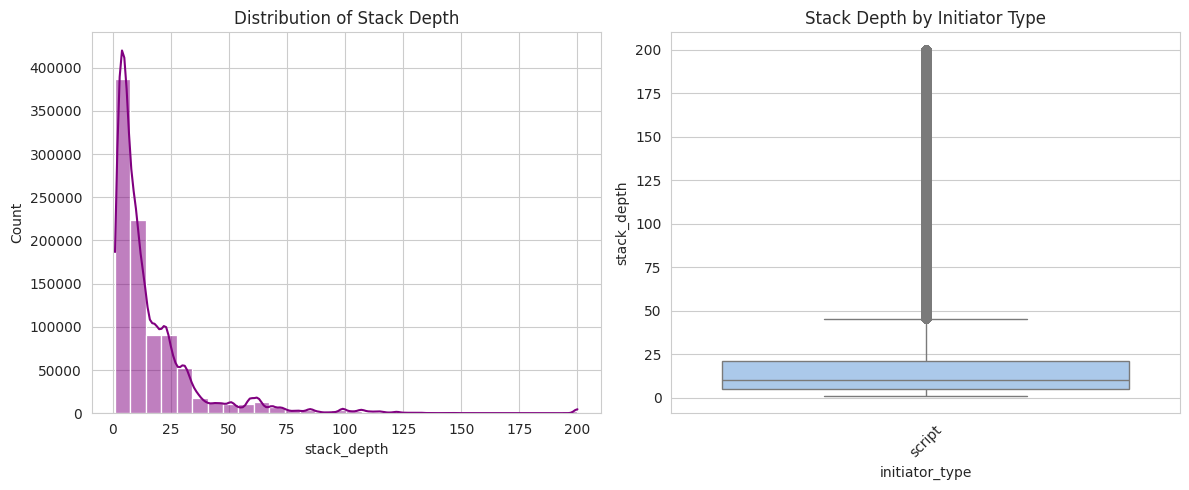

In [13]:
df_stack = df_clean.dropna(subset=['stack_depth'])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_stack['stack_depth'], bins=30, kde=True, color='purple')
plt.title('Distribution of Stack Depth')

plt.subplot(1,2,2)
sns.boxplot(data=df_stack, x='initiator_type', y='stack_depth', palette='pastel')
plt.title('Stack Depth by Initiator Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

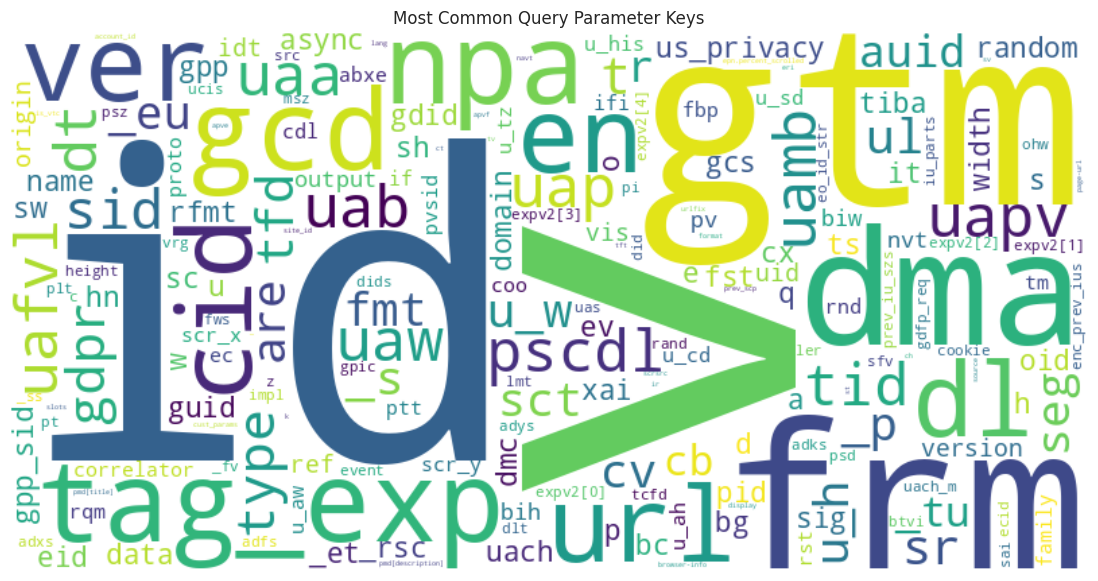

In [14]:
# Flatten all query keys
all_keys = [key for sublist in df_clean['query_keys'] for key in sublist]
key_counts = Counter(all_keys)

# Word cloud of top query parameters
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(key_counts)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Query Parameter Keys')
plt.show()

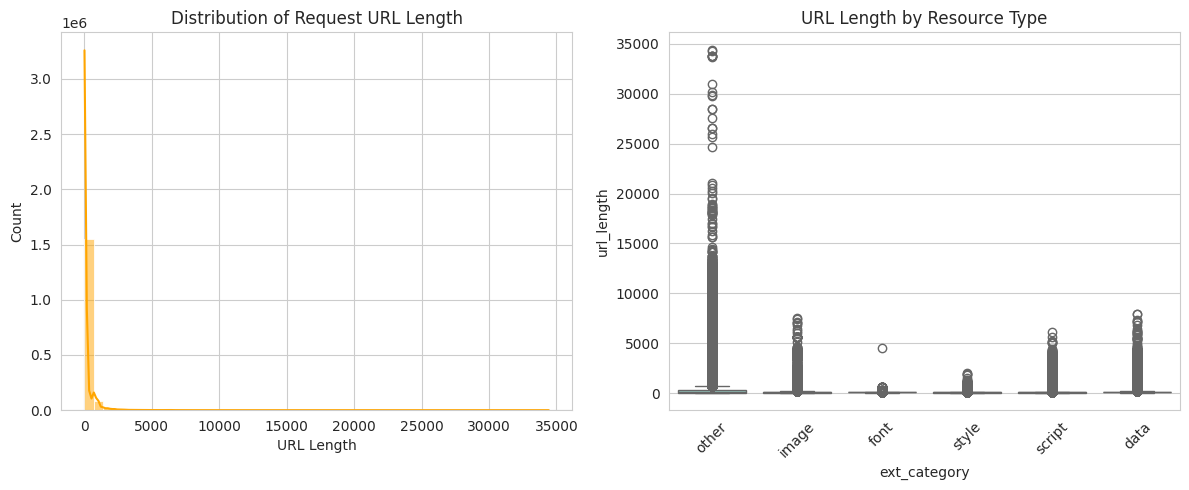

Top 20 longest URLs:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [15]:
df_clean['url_length'] = df_clean['request_url'].astype(str).apply(len)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_clean['url_length'], bins=50, kde=True, color='orange')
plt.title('Distribution of Request URL Length')
plt.xlabel('URL Length')

plt.subplot(1,2,2)
# Boxplot by file extension category (top categories)
top_cats = df_clean['ext_category'].value_counts().head(6).index
df_cats = df_clean[df_clean['ext_category'].isin(top_cats)]
sns.boxplot(data=df_cats, x='ext_category', y='url_length', palette='Set3')
plt.title('URL Length by Resource Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identify suspiciously long URLs (potential data exfiltration)
long_urls = df_clean.nlargest(20, 'url_length')[['request_url', 'domain', 'landing_domain', 'url_length']]
print("Top 20 longest URLs:")
print(long_urls.to_string())

In [36]:
# js_df = df[df['request_url'].str.contains(r'\.js(\?|$)', na=False)].copy()

In [37]:
# js_df

In [38]:
# filtered_df = js_df[~js_df['initiator'].isna()]
# filtered_df

In [39]:
# len(filtered_df)

In [40]:
# filtered_df['initiator'].iloc[0]

In [41]:
# del df

In [42]:
# js_df.request_url.iloc[0]

In [43]:
# for chunk in chunks:
#     # process each chunk
#     display(chunk.tail(5))
#     # do aggregations, filtering, writing, etc.


In [44]:
# first_chunk = next(chunks)
# print(first_chunk.head())  # show first 5 rows

# # Keep only rows where 'url' points to a JavaScript file
# js_df = chunks[0][chunks[0]['url'].str.contains(r'\.js(\?|$)', na=False)].copy()
# js_df

In [45]:
# js_df['initiator'].iloc[0]